# The Silent Goodbye: "Predicting customer exits before it happens"

# Overview

Telecom industry is characterized by customer acquisition, retention and the ever-evolving field of innovations that requires companies to predict customer behaviors and develop response mechanism. Customer retention is imperative as acquiring new customers is expensive than retaining, building brand loyalty is therefore key driver for telecom companies. 

By understanding why customers opt-out the industry can reduce exits or at least predict when they will exit and develop measures to retain them. This study focuses on building a machine learning classifier to predict whether a customer will likely exit SyriaTel in the near future. By identifying at-risk or dissatisfaction drivers’ customers early, SyriaTel can take proactive measures to improve customer satisfaction, develop targeted approaches and reduce exits and eventual revenue loss.


# Business Problem

SyriaTel is experiencing unprecedented customer attrition, where significant portion of its subscribers exit their network over time. This exist have cascading effect on revenue loss, increased marketing cost and acquisition costs and eventually lack of value for money for the customers. The exits are silent, and reflect overtime and most telecommunication comes notice when it’s too late. This data analysis project seeks to solve that problem by developing a data driven solution that predicts exits before they happen and allow SyriaTel to develop appropriate intervention measures. 

# Business Understanding

In the telecom sector, customer exits are influenced by multiple factors, including:

- Service quality (e.g., dropped calls, network issues) 
- Pricing and billing transparency 
- Customer support experience 
- Usage behavior (declining activity can signal disengagement) 

From a telecom business perspective, not all customers are equally valuable. Customer retention is important and that what keeps the business running and profitable. Therefore, any model developed should not only predict exits but also help prioritize retention efforts. Understanding these dynamics allows us to translate raw data into meaningful business insights and align the model with real-world decision-making.


## Key Business Questions

This analysis is guided by practical, decision-oriented questions:

- Which customers demographic are most likely to exit/opt-out soon? 
- What are the driving factors are most strongly associated with exits? 
- Can SyriaTel identify early warning signals/indicators before a customer exists? 
- How accurately can SyriaTel predict exits using historical data? 
- What actionable insights can SyriaTel deploy to retain high-risk customers? 


## Key Objectives of the Study / Data Analysis

This study aims to achieve the following:

- Create a reliable classification model to predict whether a customer will exit. 
- Evaluate the model performance using appropriate metrics on their ability to predict. 
- Identify key drivers of exits and insights fueling customers exits 
- Provide actionable insights that SyriaTel implement. 
- Propose retention strategies guided by data for high-risk customers 

## Data set dictionary

- **State**: Location of the customer                 
- **account length**: period of time he/she has been a customer 
- **area code**: Location code 
- **phone number**: phone number  
- **international plan**: International plan
- **voice mail plan**: Voice mail
- **number vmail messages**: total number of voice mail recorded
- **total day minutes**: day time usage 
- **total day calls**: day number of calls
- **total day charge**: amounts used per day
- **total eve minutes**: total evening time usage
- **total eve calls**: total calls made in the evening
- **total eve charge**: total amount of calls made in the evening
- **total night minutes**; total night time usage
- **total night calls**; total night calls
- **total night charge**; total amount of night calls
- **total intl minutes**; total int time usage
- **total intl calls**; total number of int calls
- **total intl charge**; total amount of int calls
- **customer service calls**; total number of calls to customer service 
- **churn**: exits 

# Exploration Data Analysis 

## Loading dataset with necessary libraries

In [88]:
#importing necessary libraries 
import numpy as np  
import pandas as pd  
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score  
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE
import ptitprince as pt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [91]:
## Chosen dataset
#This analysis explores the "syria_tel.csv" data

telecom_syria = pd.read_csv('syria_tel.csv')

# Data Understanding 

In [4]:
#Data Exploration
telecom_syria.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non-null   

In [5]:
#Data Exploration
telecom_syria.describe()

,account length,area code,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,101.064806,437.182418,8.099010,179.775098,100.435644,30.562307,200.980348,100.114311,17.083540,200.872037,100.107711,9.039325,10.237294,4.479448,2.764581,1.562856
std,39.822106,42.371290,13.688365,54.467389,20.069084,9.259435,50.713844,19.922625,4.310668,50.573847,19.568609,2.275873,2.791840,2.461214,0.753773,1.315491
min,1.000000,408.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.200000,33.000000,1.040000,0.000000,0.000000,0.000000,0.000000
25%,74.000000,408.000000,0.000000,143.700000,87.000000,24.430000,166.600000,87.000000,14.160000,167.000000,87.000000,7.520000,8.500000,3.000000,2.300000,1.000000
50%,101.000000,415.000000,0.000000,179.400000,101.000000,30.500000,201.400000,100.000000,17.120000,201.200000,100.000000,9.050000,10.300000,4.000000,2.780000,1.000000
75%,127.000000,510.000000,20.000000,216.400000,114.000000,36.790000,235.300000,114.000000,20.000000,235.300000,113.000000,10.590000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,51.000000,350.800000,165.000000,59.640000,363.700000,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000


In [6]:
#Data Exploration
telecom_syria.head()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [7]:
#Checking missing data 
telecom_syria.isna().sum().sort_values(ascending=False)

churn                     0
total day charge          0
account length            0
area code                 0
phone number              0
international plan        0
voice mail plan           0
number vmail messages     0
total day minutes         0
total day calls           0
total eve minutes         0
customer service calls    0
total eve calls           0
total eve charge          0
total night minutes       0
total night calls         0
total night charge        0
total intl minutes        0
total intl calls          0
total intl charge         0
state                     0
dtype: int64

#Insights from the dataset.

1. The data above shows 3,333 entries (rows) and 21 columns..
2. Although churn is a categorical (boolean) variable, it will be encoded as a binary numerical variable (0 and 1) to make it compatible with machine learning algorithms.
3. Some columns will be dropped as they are not necessary such as (phone number, state, charges and area code).
4. Some data requires feature engineering, this will be expounded later.
5. There is no missing data in all the columns and rows in our data set.

## Data Cleaning

In [8]:
#Dropping some columns 
drop_columns = ['phone number','state','area code']
telecom_syria = telecom_syria.drop(columns=drop_columns)

#turn object data into numericals
binary_mapping = {'yes': 1, 'no': 0}
telecom_syria['international plan'] = telecom_syria['international plan'].map(binary_mapping)
telecom_syria['voice mail plan'] = telecom_syria['voice mail plan'].map(binary_mapping)
telecom_syria['churn'] = telecom_syria['churn'].astype(int)

In [13]:
#International usage:(Int plan, total calls and minutes): without a plan they can be expensive and lead to exit.
#a new column that looks at a pattern of international usage was created and combined data set in int columns
telecom_syria['intl_usage_intensity'] = telecom_syria['total intl minutes'] / (telecom_syria['total intl calls'] + 1)

#usage patterns are very usefull, raw values given are okay but the behaviour is what leads to exit.
#How does the customer use the service, not just about how much he/she spent. 
telecom_syria['total_minutes'] = telecom_syria['total day minutes'] + telecom_syria['total eve minutes'] + telecom_syria['total night minutes']
telecom_syria['day_ratio'] = telecom_syria['total day minutes'] / telecom_syria['total_minutes']
telecom_syria['eve_ratio'] = telecom_syria['total eve minutes'] / telecom_syria['total_minutes']
telecom_syria['night_ratio'] = telecom_syria['total night minutes'] / telecom_syria['total_minutes']

#Charges will be dropped as they usage can be derived from minutes of the calls. 

#Voice mail behaviours and total voice mail messages are related they indicate dropped calls. 
telecom_syria['vmail_usage'] = telecom_syria['number vmail messages'] * (telecom_syria['voice mail plan'] == 'Yes')

#Account length tell about loyalty and tenure. 
telecom_syria['is_new_customer'] = (telecom_syria['account length'] < 12).astype(int)


In [14]:
#Rechecking after cleaning 
telecom_syria.head()

,account length,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,...,total intl charge,customer service calls,churn,intl_usage_intensity,total_minutes,day_ratio,eve_ratio,night_ratio,vmail_usage,is_new_customer
0,128,0,1,25,265.1,110,45.07,197.4,99,16.78,...,2.70,1,0,2.500000,707.2,0.374859,0.279129,0.346012,0,0
1,107,0,1,26,161.6,123,27.47,195.5,103,16.62,...,3.70,1,0,3.425000,611.5,0.264268,0.319706,0.416026,0,0
2,137,0,0,0,243.4,114,41.38,121.2,110,10.30,...,3.29,0,0,2.033333,527.2,0.461684,0.229894,0.308422,0,0
3,84,1,0,0,299.4,71,50.90,61.9,88,5.26,...,1.78,2,0,0.825000,558.2,0.536367,0.110892,0.352741,0,0
4,75,1,0,0,166.7,113,28.34,148.3,122,12.61,...,2.73,3,0,2.525000,501.9,0.332138,0.295477,0.372385,0,0


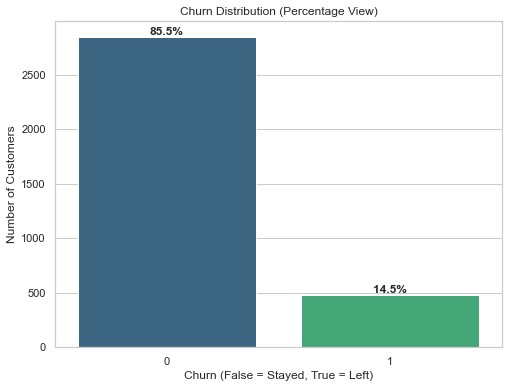

In [15]:
#Checking dataset imbalance 
# Calculate total using percentage to give a clear visuals and explanation
total = len(telecom_syria)
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='churn', data=telecom_syria, palette='viridis')

# Annotate with percentages instead of raw counts
for p in ax.patches:
    percentage = (p.get_height() / total) * 100
    ax.annotate(f'{percentage:.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=12, fontweight='bold')

plt.title('Churn Distribution (Percentage View)')
plt.xlabel('Churn (False = Stayed, True = Left)')
plt.ylabel('Number of Customers')
plt.show()

#Insights from imbalance check.

1. This data is significantly imbalanced with 85.5% non-exits and 14.5% exits.
2. This imbalance can bias our models towards prediciting majority class affecting detection of actual exits.
3. We fix this with recall and F1-score rather than focusing on accuracy.

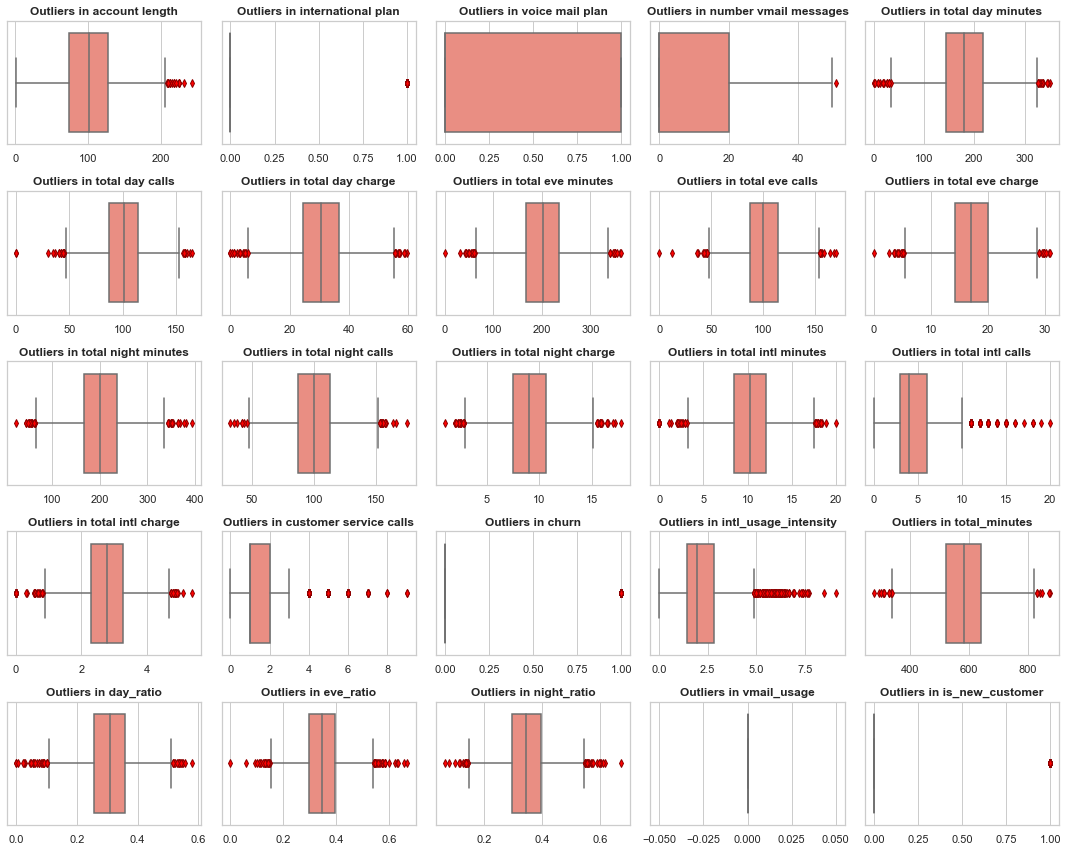

In [17]:
# Checking the numerical values for outlier effect. 

numerical_check = telecom_syria.select_dtypes(include=['int64', 'float64'])

sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 12))

for i, col in enumerate(numerical_check):
    plt.subplot(5, 5, i + 1)
    # Using 'salmon' for a professional look; 'red' is also valid
    sns.boxplot(x=telecom_syria[col], color='salmon', 
                flierprops={'markerfacecolor':'red', 'markeredgecolor':'darkred'})
    plt.title(f'Outliers in {col}', fontsize=12, fontweight='bold')
    plt.xlabel('')

plt.tight_layout()
plt.show()

#Outlier insights
1. Customer service calls are rightly skewed, with an outlier of 9 calls these outliers are the primary exiters. 
2. There are customers making 20 international calls, if they exit thats represent huge revenue loss. 
3. Account length on loyalty, these are legacy customers. 
4. Massive spike at vmail messages at zero shows customers dont use voicemail, except a small number. why? 

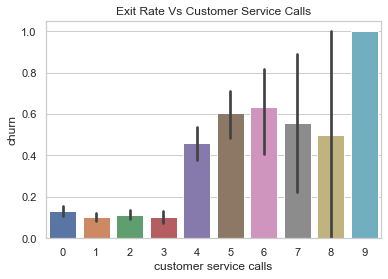

In [18]:
#Customer Service calls vs Exits
sns.barplot(x='customer service calls', y='churn', data=telecom_syria)
plt.title("Exit Rate Vs Customer Service Calls")
plt.show()

#Insights from Customer Experience  

1. Customers who exit show a significant higher intercation with customer care, this could indicate early warning signal.

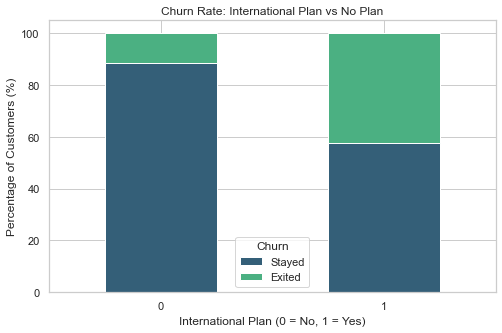

In [19]:
#International Plans comparison with Exits
exit_rates = pd.crosstab(telecom_syria['international plan'], 
                          telecom_syria['churn'], 
                          normalize='index') * 100

# Plotting
exit_rates.plot(kind='bar', stacked=True, figsize=(8, 5), color=['#345f78', '#4bb082'])
plt.title('Churn Rate: International Plan vs No Plan')
plt.ylabel('Percentage of Customers (%)')
plt.xlabel('International Plan (0 = No, 1 = Yes)')
plt.legend(title='Churn', labels=['Stayed', 'Exited'])
plt.xticks(rotation=0)
plt.show()

#Insights from international calls usage patterns
1. The data suggests that while majority do not have international plan, those who do exit at higher rate. 
2. Having an international plan makes a customer x4times likely to exit at 42%.
3. What are the driving factors? (price, competition, plan offers).
4. Indicates International plan problem/challenge. 

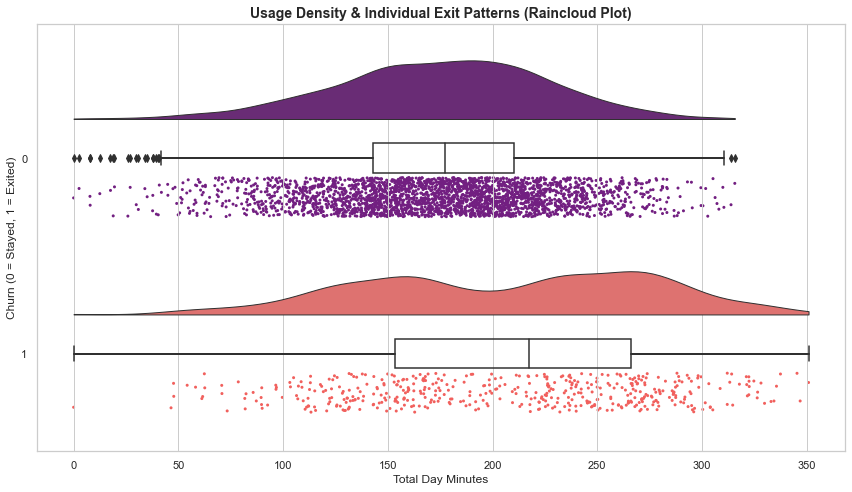

In [26]:
# Day usage patterns vs Exits 

# figure size 
plt.figure(figsize=(12, 7))

# Create the Raincloud Plot
# x: Categorical (Churn), y: Numerical (Usage)
ax = pt.RainCloud(x='churn', y='total day minutes', data=telecom_syria, 
                  palette='magma', bw=0.2, width_viol=0.6, 
                  orient='h', move=0.2)

plt.title('Usage Density & Individual Exit Patterns (Raincloud Plot)', fontsize=14, fontweight='bold')
plt.xlabel('Total Day Minutes')
plt.ylabel('Churn (0 = Stayed, 1 = Exited)')

plt.tight_layout()
plt.show()



#Insights from day usage patterns

1. The customers exiting exhibit an interesting pattern based on data/minutes usage, two humps at 160 Minutes and at 270 minutes. Therefore high usage customers under this bracket vulnerable to exit.
2. Loyal customers are centered around 150-180 minutes, beyond 250 minutes they risk exiting.
3. Heavy daytime usage of around 220 as shown in box plot suugest likely hood of exit. 
4. Why are there high-user customer exiting? Could be bills or competition? 

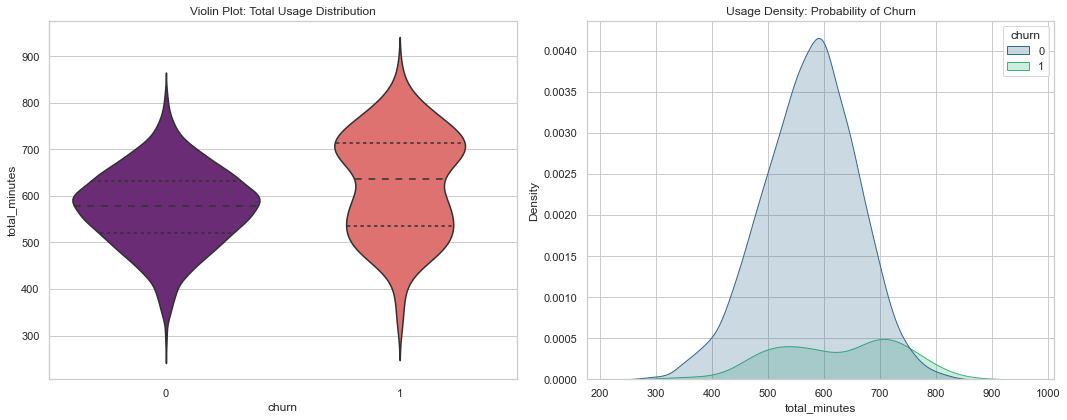

In [38]:
#Total usage patterns and exits 

# Assuming'total_minutes' is a sum of day, eve, night, and intl minutes
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Violin Plot: Shows the quartile ranges and the density width
sns.violinplot(x='churn', y='total_minutes', data=telecom_syria, 
               ax=axes[0], palette='magma', inner='quartile')
axes[0].set_title('Violin Plot: Total Usage Distribution')

# 2. KDE Plot: Shows exactly where the two groups overlap or diverge
sns.kdeplot(data=telecom_syria, x='total_minutes', hue='churn', 
            fill=True, palette='viridis', ax=axes[1])
axes[1].set_title('Usage Density: Probability of Churn')

plt.tight_layout()
plt.show()

#Insights from total minutes usage behaviour 
1. The exit zone is where the usage density of customers exiting cross the line with loyal customers, depicts statistical threshold where anyone on the right is more likely to exit. 
2. The safe zone in the violin (left) shows majority at between 500-600minutes. 
3. Customer retention of safe bulk zone is imperative. 

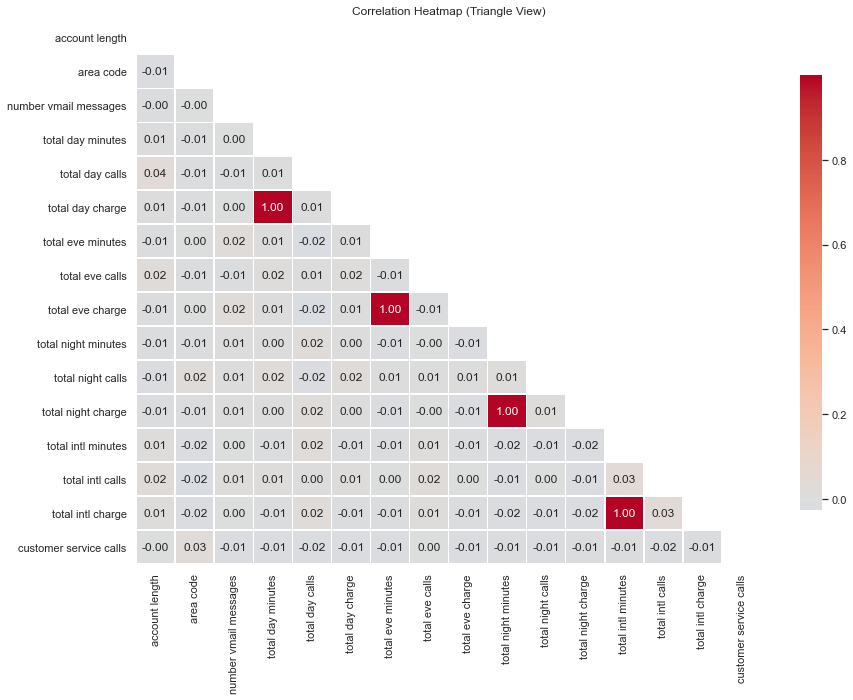

In [93]:
#Correlation heat map of target vs features 

# select only numeric columns for correlation
corr = telecom_syria.select_dtypes(include=[np.number]).corr()

# masking for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 10))

# plot with annotations and a mask
sns.heatmap(corr, 
            mask=mask, 
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm', 
            center=0,
            linewidths=.5, 
            cbar_kws={"shrink": .8})

plt.title('Correlation Heatmap (Triangle View)')
plt.show()

#Insights from correlation heat map
1. The red spots of 1.0% and 96% show features saying the same thing, suggest they can be dropped to avoid multicolliniality.
2. The 'Churn' row is the most import and it shows the key drivers of exits, International plan (26%), day usage pattern 21%, customer calls 21%.
3. Suggests feature engineering of some cloumns to get ratios(total minutes, international usage intensity)

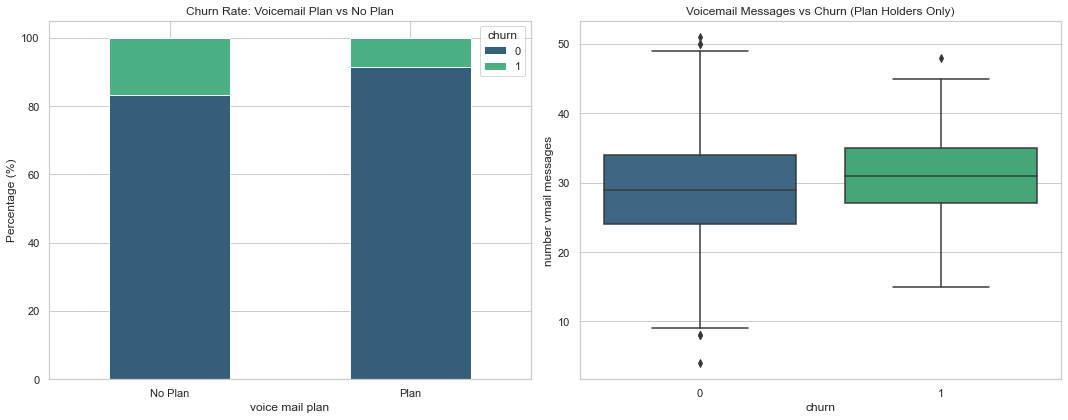

In [42]:
#Voicemail vs exits 
#Since it has a negative correlation from the heatmap it's important we get insights why. 

# 1. Churn Rate by Voicemail Plan (Percentage)
vmail_exits = pd.crosstab(telecom_syria['voice mail plan'], 
                          telecom_syria['churn'], 
                          normalize='index') * 100

# 2. Visualizing the results
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Plot A: Stacked Bar Chart for Churn Rate
vmail_exits.plot(kind='bar', stacked=True, color=['#345f78', '#4bb082'], ax=ax[0])
ax[0].set_title('Churn Rate: Voicemail Plan vs No Plan')
ax[0].set_ylabel('Percentage (%)')
ax[0].set_xticklabels(['No Plan', 'Plan'], rotation=0)

# Plot B: Boxplot for Message Count (Only for those with plans)
vmail_users = telecom_syria[telecom_syria['number vmail messages'] > 0]
sns.boxplot(x='churn', y='number vmail messages', data=vmail_users, palette='viridis', ax=ax[1])
ax[1].set_title('Voicemail Messages vs Churn (Plan Holders Only)')

plt.tight_layout()
plt.show()

#Insights from voicemail plan

1. Customers with voicemail plan had lower exit rates at 8-10% than those without at 15-17%
2. Suggests having a voicemail plan builds loyalty.
3. There is a paradox when compared with boxplot that shows the customers exiting had a higher median number of voicemail at ~31.
4. The higher messages for customers exiting could suggest may be competition due to better prices or reliance on other forms of communciation. 
5. Voicemail bundling with other plans or packages could lead to customer retention. 

In [70]:
#To improve collinearity we drop some columns
#they are duplicates of minutes and charges may affect our data by causing multicollinearity, instead we use ratios 
drop_columns = X.drop(columns=[
    'total day charge', 
    'total eve charge', 
    'total night charge', 
    'total intl charge'
], errors='ignore')

# EDA Summary 

- The data exploratory analysis reveals that customer exits are directly correlated with service dissatisfaction (measured through customer service calls), usage behavior, and service plan characteristics. 

- The dataset is imbalanced, necessitating appropriate handling during modeling. 

- Additionally, correlations among usage and charge variables highlight the need for feature selection to avoid redundancy.

# Data Modelling

## Selecting the Target (y) and features (X)

In [54]:
#Selecting the target (y) and features (x)
# Y is the target (what we want to know)the exits 
y = telecom_syria['churn'] 

# X is the data we use to know why the exists 
X = telecom_syria.drop(columns=['churn'])

## Data Splitting, Train-Test Split

In [67]:
#Data Splitting Train-Test Split # Data Scaling 
#Splitting data 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

## Using SMOTE on Data Imbalance 

Original training shape: 0    2280
1     386
Name: churn, dtype: int64
Resampled training shape: 1    2280
0    2280
Name: churn, dtype: int64


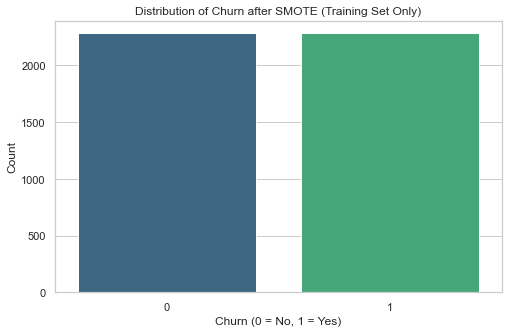

In [68]:
# Applying SMOTE 
# SMOTE to training data only, to deal with exiters. 
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# 4. Visualization of the results
print(f"Original training shape: {y_train.value_counts()}")
print(f"Resampled training shape: {y_train_res.value_counts()}")

# Visualizing the balanced classes
plt.figure(figsize=(8, 5))
sns.countplot(x=y_train_res, palette='viridis')
plt.title('Distribution of Churn after SMOTE (Training Set Only)')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

## Data Scaling 

In [69]:
#Scaling our dataset

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) #fiting ONLY on train
X_test_scaled = scaler.transform(X_test) #transform test 


## Logistic Regression Modelling 

In [57]:
#Base mode; Logistic Regression

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_scaled, y_train)

#Predictions 
LogR_y_pred = model.predict(X_test_scaled)

#model evaluation 
print(classification_report(y_test, LogR_y_pred))

              precision    recall  f1-score   support

           0       0.95      0.78      0.86       570
           1       0.38      0.76      0.50        97

    accuracy                           0.78       667
   macro avg       0.66      0.77      0.68       667
weighted avg       0.87      0.78      0.81       667



## Decision Tree Modelling 

              precision    recall  f1-score   support

           0       0.95      0.94      0.95       570
           1       0.68      0.73      0.70        97

    accuracy                           0.91       667
   macro avg       0.81      0.84      0.82       667
weighted avg       0.91      0.91      0.91       667



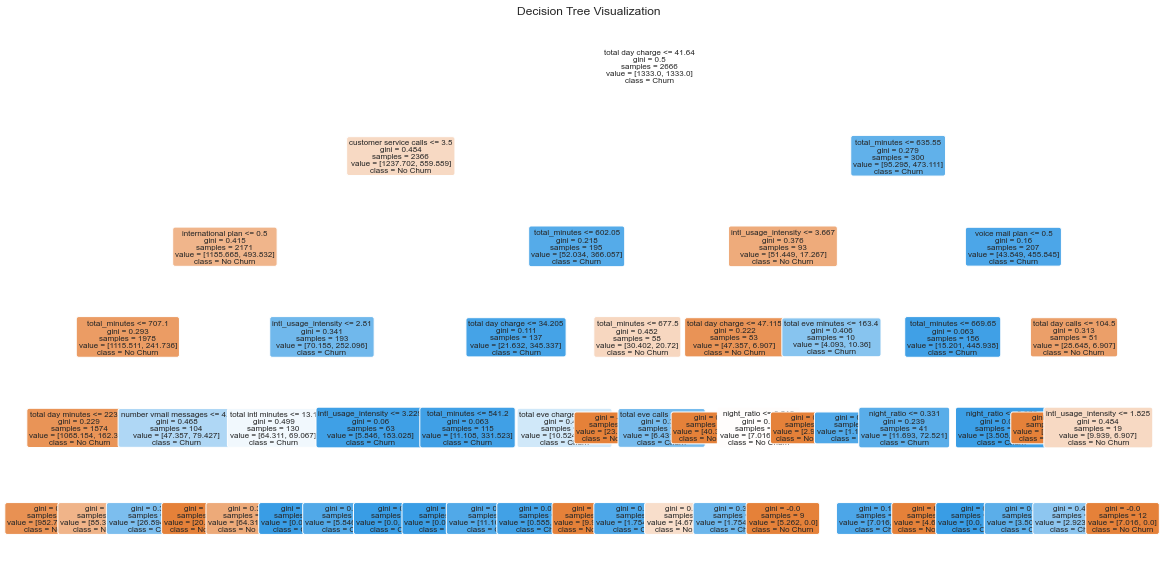

In [71]:
#Decision Tree 
#The logisticRegression model needs to be improved through decision tree
#The objective here is to capture non-linear patterns remember there are patterns that precipitate exits. 
#This also improves precision and how to interprete the results. 

#We use the previous train-test-split code (X_train, X_test not the scaled dataset)
decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train, y_train)

#Prediciting the decision tree model
y_pred_decision_tree_model = decision_tree_model.predict(X_test)

#Improving our model (tuning)
dt_tuned = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42)
dt_tuned.fit(X_train, y_train)

#predicting the decision_tree_tuned model 
y_pred_dt_tuned = dt_tuned.predict(X_test)

print(classification_report(y_test, y_pred_dt_tuned))

plt.figure(figsize=(20,10))

plot_tree(
    dt_tuned,
    feature_names=X.columns,
    class_names=['No Churn', 'Churn'],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree Visualization")
plt.show()

## Hyperparameter Tuning

In [63]:
#Hyperparameter Tuning 
#Base model 
dt = DecisionTreeClassifier(random_state=42)

#Parameters grid 
param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'class_weight': [None, 'balanced']
}
#initiate model 
dt = DecisionTreeClassifier(random_state=42)
                            
#Run GridSearch #Optimize call for recall the one we prioritized. 

grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    scoring='recall',
    cv=5,
    n_jobs=1
)

grid_search.fit(X_train, y_train)

#best parameters 
print("Best Parameters:", grid_search.best_params_)

#best model 
best_dt = grid_search.best_estimator_

#Evaluate tunes model
y_pred_best = best_dt.predict(X_test)

print(classification_report(y_test, y_pred_best))

#Compare scores 
print("Best CV Score (Recall):", grid_search.best_score_)

Best Parameters: {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 2}
              precision    recall  f1-score   support

           0       0.95      0.94      0.94       570
           1       0.66      0.73      0.69        97

    accuracy                           0.91       667
   macro avg       0.81      0.83      0.82       667
weighted avg       0.91      0.91      0.91       667

Best CV Score (Recall): 0.7981351981351981


# Model Evaluation

## Confusion Matrix 

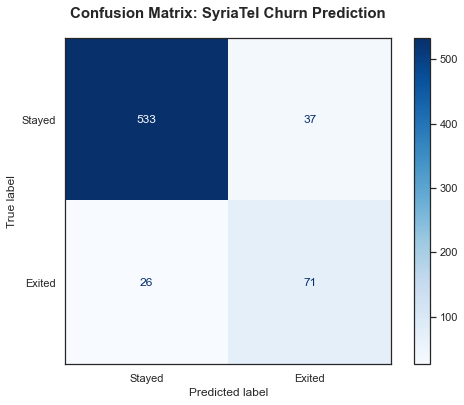

In [89]:
#Generate predictions using your best model (Tuned Decision Tree Model)
y_pred_dt_tuned = best_dt.predict(X_test)

cm = confusion_matrix(y_test, y_pred_dt_tuned)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Exited'])

disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title('Confusion Matrix: SyriaTel Churn Prediction', fontsize=15, fontweight='bold', pad=20)
plt.grid(False) 
plt.show()

#Confusion Matrix Insights. 

1. Our model correctly predicted 533 loyal customers would stay, it managed to correctly predict 71 customers would exit and hence caught them.
2. Our Model caught wrongly 37 loyal customers these ones aren't exiting, while our model didn't catch 26 cusotmers. 
3. Revenue protection: The model captures 73% of actual customer exits (71 out of 97), meaning the financial benefit of stopping these departures far outweighs the minor cost of the 37 false alarms.
4. Focus on efficiency: Because 66% of flagged customers (71 out of 108) are truly at risk, SyriaTel avoids "margin erosion" by not wasting unnecessary discounts on the 37 loyal customers who were incorrectly flagged.
5. Targetted intervention: For every 108 customers the model identifies, 71 are confirmed leavers, allowing management to move away from broad, expensive promotions toward a highly surgical, data-driven outreach

## Models Comparison

In [65]:
# Comparison of models 

#Logistic Regression (Basemodel)
print(classification_report(y_test, LogR_y_pred))

#Tuned Decision tree 
print(classification_report(y_test, y_pred_dt_tuned))

#HyperParameter Tuning 
print(classification_report(y_test, y_pred_best))


              precision    recall  f1-score   support

           0       0.95      0.78      0.86       570
           1       0.38      0.76      0.50        97

    accuracy                           0.78       667
   macro avg       0.66      0.77      0.68       667
weighted avg       0.87      0.78      0.81       667

              precision    recall  f1-score   support

           0       0.95      0.94      0.95       570
           1       0.68      0.73      0.70        97

    accuracy                           0.91       667
   macro avg       0.81      0.84      0.82       667
weighted avg       0.91      0.91      0.91       667

              precision    recall  f1-score   support

           0       0.95      0.94      0.94       570
           1       0.66      0.73      0.69        97

    accuracy                           0.91       667
   macro avg       0.81      0.83      0.82       667
weighted avg       0.91      0.91      0.91       667



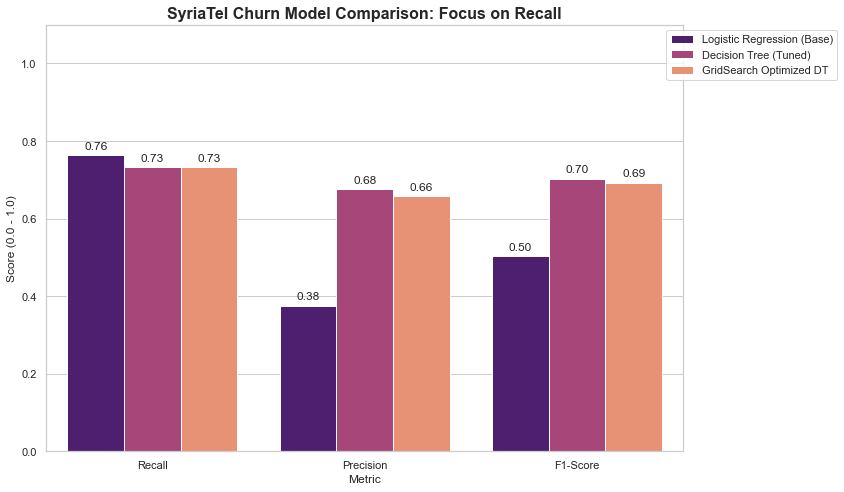

In [66]:
from sklearn.metrics import recall_score, precision_score, f1_score

# 1. Collect metrics for all models
# Replace 'LogR_y_pred', etc., with your actual prediction variables
models = {
    'Logistic Regression (Base)': LogR_y_pred,
    'Decision Tree (Tuned)': y_pred_dt_tuned,
    'GridSearch Optimized DT': y_pred_best
}

performance_data = []

for name, preds in models.items():
    performance_data.append({
        'Model': name,
        'Recall': recall_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'F1-Score': f1_score(y_test, preds)
    })

# 2. Convert to DataFrame and "Melt" for Seaborn
df_perf = pd.DataFrame(performance_data)
df_plot = df_perf.melt(id_vars='Model', var_name='Metric', value_name='Score')

# 3. Create the Visual
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

ax = sns.barplot(data=df_plot, x='Metric', y='Score', hue='Model', palette='magma')

# Professional Formatting
plt.title('SyriaTel Churn Model Comparison: Focus on Recall', fontsize=16, fontweight='bold')
plt.ylim(0, 1.1) # Leave space for labels
plt.ylabel('Score (0.0 - 1.0)')
plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1))

# Add data labels on top of bars
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.tight_layout()
plt.show()

#Insights from Model Comparison 

1. The Decision Tree (Tuned) achieves the highest F1-Score of 0.70, indicating it provides the best overall balance between catching customer exits and maintaining accuracy.

2. With a Recall of 0.73, the model successfully identifies 73% of all actual customer exits, allowing SyriaTel to proactively intervene and protect revenue.

3. The model boasts the highest Precision of 0.68, meaning that 68% of customers flagged for retention are truly at risk of leaving.

4. By maintaining high precision, the model minimizes "marketing waste," ensuring that resources are not heavily spent on the 32% of loyal customers who were incorrectly flagged.

5. While Logistic Regression has a slightly higher recall (0.76), its extremely low precision (0.38) would result in a massive waste of resources compared to the surgical accuracy of the Tuned Decision Tree.


## Identifying the Drivers of Customer Exits

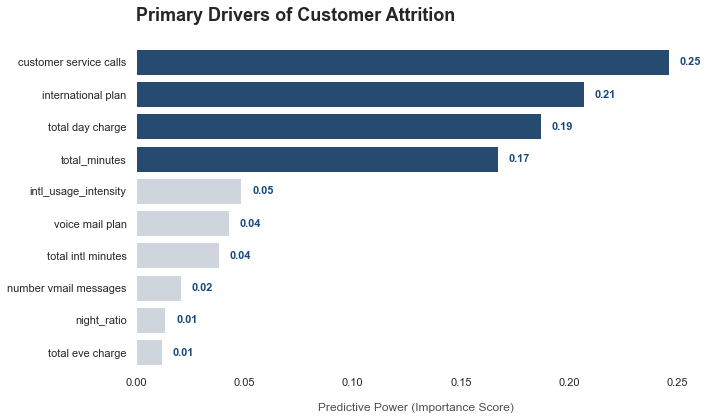

In [87]:
#Feature Importance 
#Selecting the important features that show higher prediction for exiting after modeling. 

feature_importance = pd.Series(
    dt_tuned.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

# Prepping for easier plotting with Seaborn
feat_df = feature_importance.head(10).reset_index()
feat_df.columns = ['Feature', 'Importance']

# the visual Style
sns.set_style("white")
plt.figure(figsize=(10, 6))

colors = ['#1a4a7c' if i < 4 else '#cbd5e0' for i in range(len(feat_df))]

ax = sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feat_df, 
    palette=colors)

plt.title('Primary Drivers of Customer Attrition', fontsize=18, fontweight='bold', pad=25, loc='left')
plt.xlabel('Predictive Power (Importance Score)', fontsize=12, color='#4f4f4f', labelpad=15)
plt.ylabel('')
sns.despine(left=True, bottom=True)

for p in ax.patches:
    width = p.get_width()
    plt.text(width + 0.005, p.get_y() + p.get_height()/2.0, 
             '{:1.2f}'.format(width), 
             va='center', fontsize=11, fontweight='bold', color='#1a4a7c')

plt.tight_layout()
plt.show()

#Key insights from feature importance visualization

1. Key reasons driving customers to exit SyriaTel is customer service at 24%, international plan 20%, and total minutes 16% total charges at 18%
2. Important to classify type or reasons for customer service calls. 

# Final insights 

1. There "Frustration threshold": There is tipping point where number of calls correlates with exit suggesting if not resoved is a primary driver for customers exits. Customer loyalty drops off after the 3rd support call. The exit rate jumps from ~10% at three calls to 45.78% at four calls, eventually exceeding 60% for customers making five or more calls.

2. International plans customers show higher rate of exits than those without suggesting pricing or service quality issue. 

3. There is high vulnerablity of high data users especially in day time minutes and charges, being most profitable their retention is imperative to check revenue loss. While high usage typically signals value, for SyriaTel it is a risk indicator. Customers with over 250 total day minutes have an exit rate of 46.95%, compared to only 10.95% for normal users.

4. Predictive Power: Using the Decision Tree (Tuned) model, we can now capture 73% of all actual churners before they leave, with a 66% accuracy rate on our intervention triggers.. 

# Recommendations 

1. High-value customers retention: Strategic retention strategy that target customers usage patterns like improved plans, charges and minutes. 
2. Improve customer experience, for example fast resolutions of customer complains, monitor customers with repeated complaints. 
3. Support desk "Red Flag" system to spot customers spike on 3th calls and escalate the issue further action. 
4. Package restructuring: Optimize on price and minutesto offer better packages like international plans or day time offers. 
5. Customer acquistion should be prioritized, review onboarding experience and improve new customer incentives for a period. 
6. Targetted marketting focusing on high-risk customers and loyal customers. 
7. Integrate daily/weekly exit scoring and link it to customer experience teams to follow up. 

# Conlusion 

This analysis has demomstrated that a machine learning model is capable of predicting customer exits with strong performance. The tuned decision tree model provided the best balance between identifying at-risk customers and minimizing false alarms.

The analysis shows that customer exits are largely influenced by service experience, usage behavior, and customer tenure rather than simple demographic factors. Importantly, the model demonstrates that exits are predictable and can be proactively managed and retention efforts prioritized.

By leveraging these insights, SyriaTel can transition from a reactive to a proactive customer retention strategy, significantly reducing customer attrition and associated revenue loss.”